# 03 Keypose Marking

Instructor workflow to populate `master_data/chon_ji/keyposes_angles.json`.

**Goal**: Mark the completion frame of each of the 19 Chon-Ji movements so that
`segment_movements()` can achieve **"high" confidence** (both velocity valley AND
keypose signal agree within 5 frames).

## Workflow
1. **Auto-detect** 19 candidate frames from velocity valleys (run once)
2. **Watch** `chon_ji_master_overlay.mp4` and adjust `KEYPOSE_FRAMES` as needed
3. **Build** angle entries and save `keyposes_angles.json`
4. **Re-run** `segment_movements()` → verify high confidence ≥ 15/19


## Setup

In [95]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent.parent))

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from itf_analysis.segmentation.segmentor import load_poses_from_json
from itf_analysis.normalization.normalizer import normalize_pose, extract_joint_angles
from itf_analysis.segmentation.velocity_detector import (
    compute_motion_velocity, smooth_velocity, find_velocity_valleys,
)
from itf_analysis.segmentation.segmenter import segment_movements
from itf_analysis.segmentation.keypose_matcher import load_master_keyposes
from itf_analysis.segmentation.keypose_angle_marker import (
    build_angle_entry,
    save_keyposes_angles,
    load_keyposes_angles_or_empty,
    validate_keyposes_angles,
)

PROJECT_ROOT = pathlib.Path.cwd().parent.parent

# ── CONFIG ────────────────────────────────────────────────────────────────────
POOMSAE       = "do_san"   # change this value for a new poomsae
NUM_MOVEMENTS = 24           # number of movements in poomsae (chon_ji=19, dan_gun=21, do_san=24 etc.)
# ──────────────────────────────────────────────────────────────────────────────

poomsae_dir = PROJECT_ROOT / "itf_analysis" / "sample_videos" / POOMSAE
POSES_PATH  = str(poomsae_dir / "master_poses.json")
OUTPUT_PATH = str(PROJECT_ROOT / "itf_analysis" / "master_data" / POOMSAE / "keyposes_angles.json")

print(f"Poses  : {POSES_PATH}")
print(f"Output : {OUTPUT_PATH}")

Poses  : E:\Projects\Saas\Taekwon\itf_analysis\sample_videos\do_san\master_poses.json
Output : E:\Projects\Saas\Taekwon\itf_analysis\master_data\do_san\keyposes_angles.json


## Step 0 — Load poses and extract angles

In [96]:
frames = load_poses_from_json(POSES_PATH)
fps = 1000.0 / (frames[1].timestamp_ms - frames[0].timestamp_ms)

all_frame_angles = []
for fr in frames:
    norm = normalize_pose(fr.landmarks)
    if norm is None:
        continue
    all_frame_angles.append((fr.frame_index, extract_joint_angles(norm)))

# Build frame → angles lookup for later
angles_by_frame = {fi: fa for fi, fa in all_frame_angles}

print(f"Frames loaded : {len(frames)}")
print(f"FPS           : {fps:.1f}")
print(f"Angle frames  : {len(all_frame_angles)}")

Frames loaded : 1283
FPS           : 30.0
Angle frames  : 1283


## Step 1 — Auto-detect velocity candidate frames

Run velocity pipeline to get 19 candidate frames.  
These are used as starting points — adjust them in `KEYPOSE_FRAMES` below.

In [98]:
frame_indices = [fi for fi, _ in all_frame_angles]

# ── SET THIS before running ───────────────────────────────────────────────────
END_FRAME = 1200   # last frame of poomsae — return-to-ready occurs after this frame
# ─────────────────────────────────────────────────────────────────────────────

velocity = compute_motion_velocity(all_frame_angles, fps)
smoothed = smooth_velocity(velocity, fps, sigma_seconds=0.1)
valleys  = find_velocity_valleys(smoothed, fps, min_gap_sec=0.5)

# avg_mov: based on END_FRAME — including return-to-ready frames would inflate avg_mov,
# causing the search window near the last movement to exceed END_FRAME and become inaccurate
total_range = END_FRAME - frame_indices[0]
avg_mov     = total_range / NUM_MOVEMENTS
half_window = max(1, int(avg_mov * 0.45))

print(f"Full range : {frame_indices[0]}–{frame_indices[-1]}")
print(f"END_FRAME  : {END_FRAME}")
print(f"avg_mov    : {avg_mov:.1f} frames   half_window : {half_window}")

candidate_frames = {}
prev      = frame_indices[0] - 1
last_det  = frame_indices[0]

for i in range(NUM_MOVEMENTS):
    mov = i + 1
    exp = round(last_det + avg_mov)

    lo = max(frame_indices[0], prev + 1, exp - half_window)
    hi = min(END_FRAME, exp + half_window)
    if hi >= END_FRAME:
        lo = max(frame_indices[0], prev + 1)
    if lo > hi:
        lo = hi = exp

    in_window = [v for v in valleys if lo <= frame_indices[v] <= hi]
    if in_window:
        best_v = min(in_window, key=lambda v: smoothed[v])
        candidate_frames[mov] = frame_indices[best_v]
    else:
        candidate_frames[mov] = exp

    last_det = candidate_frames[mov]
    prev     = candidate_frames[mov]

print(f"\nVelocity candidate frames:")
for mov, fr in candidate_frames.items():
    print(f"  Movement {mov:2d}: frame {fr}")

Full range : 0–1282
END_FRAME  : 1200
avg_mov    : 50.0 frames   half_window : 22

Velocity candidate frames:
  Movement  1: frame 54
  Movement  2: frame 100
  Movement  3: frame 169
  Movement  4: frame 216
  Movement  5: frame 269
  Movement  6: frame 320
  Movement  7: frame 370
  Movement  8: frame 398
  Movement  9: frame 450
  Movement 10: frame 508
  Movement 11: frame 558
  Movement 12: frame 620
  Movement 13: frame 670
  Movement 14: frame 724
  Movement 15: frame 757
  Movement 16: frame 807
  Movement 17: frame 871
  Movement 18: frame 921
  Movement 19: frame 949
  Movement 20: frame 1007
  Movement 21: frame 1048
  Movement 22: frame 1086
  Movement 23: frame 1125
  Movement 24: frame 1175


## Step 2 — Set `KEYPOSE_FRAMES`

**Instructions:**
1. Watch `sample_videos/{POOMSAE}/master_overlay.mp4` (or `master.mp4`)
2. For each movement, find the exact frame where the technique is fully completed  
   (body fully stopped, final posture held)
3. Update the frame numbers below — the candidate values are pre-filled from velocity detection
4. Update `MOVEMENT_META` below with the correct names for all `NUM_MOVEMENTS` techniques

In [99]:
# ── EDIT THESE FRAME NUMBERS ──────────────────────────────────────────────────
KEYPOSE_FRAMES = {mov: fr for mov, fr in candidate_frames.items()}

# Manual overrides — uncomment and edit as needed:
# KEYPOSE_FRAMES[1]  = 87
# ─────────────────────────────────────────────────────────────────────────────

# ── MOVEMENT METADATA ─────────────────────────────────────────────────────────
# Format: {movement_number: ("internal_snake_case_name", "ITF technique name")}
# For a NEW poomsae: clear this dict and fill in your own entries.
# Movements not listed here get auto-generated generic names.
MOVEMENT_META = {
    1:  ("left_walking_high_block",           "Ap Kubi Olgul Makgi (L)"),
    2:  ("right_walking_middle_punch",         "Ap Kubi Kaunde Jirugi (R)"),
    3:  ("right_walking_high_block",           "Ap Kubi Olgul Makgi (R)"),
    4:  ("left_walking_middle_punch",          "Ap Kubi Kaunde Jirugi (L)"),
    5:  ("left_l_stance_inner_forearm_block",  "Niunja Sogi An Palmok Makgi (L)"),
    6:  ("right_walking_middle_punch_2",       "Ap Kubi Kaunde Jirugi (R)"),
    7:  ("right_l_stance_inner_forearm_block", "Niunja Sogi An Palmok Makgi (R)"),
    8:  ("left_walking_middle_punch_2",        "Ap Kubi Kaunde Jirugi (L)"),
    9:  ("left_walking_low_block",             "Ap Kubi Najunde Makgi (L)"),
    10: ("right_walking_middle_punch_3",       "Ap Kubi Kaunde Jirugi (R)"),
    11: ("right_walking_low_block",            "Ap Kubi Najunde Makgi (R)"),
    12: ("left_walking_middle_punch_3",        "Ap Kubi Kaunde Jirugi (L)"),
    13: ("left_walking_middle_punch_4",        "Ap Kubi Kaunde Jirugi (L) x2"),
    14: ("right_walking_middle_punch_4",       "Ap Kubi Kaunde Jirugi (R)"),
    15: ("left_l_stance_knifehand_block",      "Niunja Sogi Sonkal Makgi (L)"),
    16: ("right_walking_middle_punch_5",       "Ap Kubi Kaunde Jirugi (R)"),
    17: ("right_l_stance_knifehand_block",     "Niunja Sogi Sonkal Makgi (R)"),
    18: ("left_walking_middle_punch_5",        "Ap Kubi Kaunde Jirugi (L)"),
    19: ("left_walking_middle_punch_final",    "Ap Kubi Kaunde Jirugi (L) — final"),
    # ── Do-San movements 20-24: update names below to match actual techniques ──
    20: ("movement_20",  "Movement 20"),
    21: ("movement_21",  "Movement 21"),
    22: ("movement_22",  "Movement 22"),
    23: ("movement_23",  "Movement 23"),
    24: ("movement_24",  "Movement 24"),
}
# ─────────────────────────────────────────────────────────────────────────────

def _get_meta(mov: int):
    if mov in MOVEMENT_META:
        return MOVEMENT_META[mov]
    return (f"movement_{mov}", f"Movement {mov}")

print("KEYPOSE_FRAMES:")
for mov, fr in KEYPOSE_FRAMES.items():
    name, itf = _get_meta(mov)
    print(f"  {mov:2d}  frame {fr:5d}  {name}")

KEYPOSE_FRAMES:
   1  frame    54  left_walking_high_block
   2  frame   100  right_walking_middle_punch
   3  frame   169  right_walking_high_block
   4  frame   216  left_walking_middle_punch
   5  frame   269  left_l_stance_inner_forearm_block
   6  frame   320  right_walking_middle_punch_2
   7  frame   370  right_l_stance_inner_forearm_block
   8  frame   398  left_walking_middle_punch_2
   9  frame   450  left_walking_low_block
  10  frame   508  right_walking_middle_punch_3
  11  frame   558  right_walking_low_block
  12  frame   620  left_walking_middle_punch_3
  13  frame   670  left_walking_middle_punch_4
  14  frame   724  right_walking_middle_punch_4
  15  frame   757  left_l_stance_knifehand_block
  16  frame   807  right_walking_middle_punch_5
  17  frame   871  right_l_stance_knifehand_block
  18  frame   921  left_walking_middle_punch_5
  19  frame   949  left_walking_middle_punch_final
  20  frame  1007  movement_20
  21  frame  1048  movement_21
  22  frame  1086  mov

## Step 2b — Visualise candidate frames on velocity curve

Check that each marked frame sits near a velocity valley.  
Frames far from a valley may need manual correction.

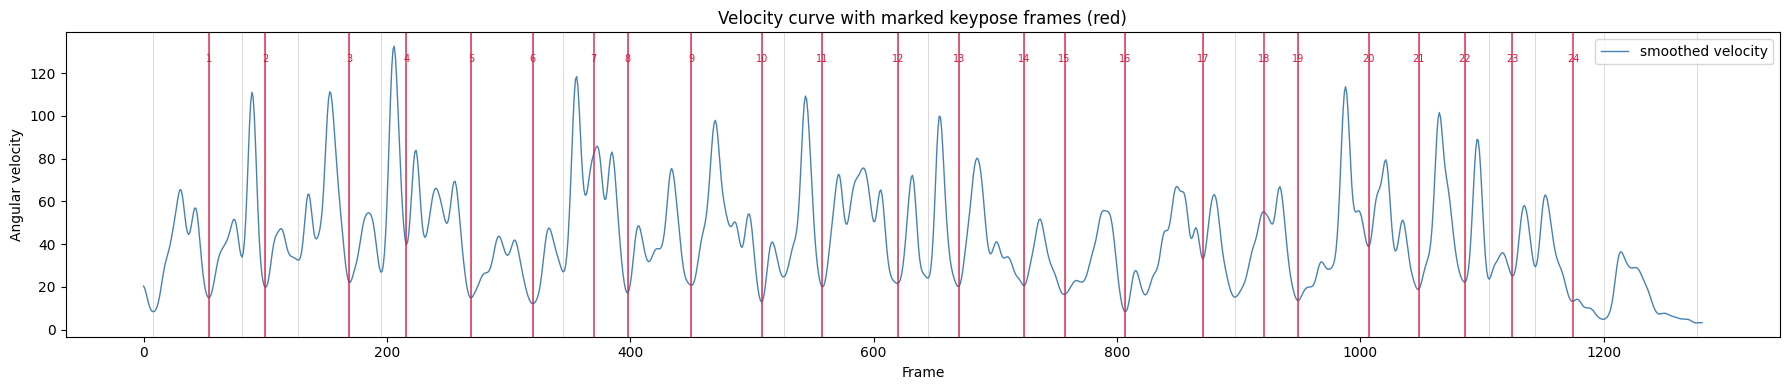

In [100]:
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(frame_indices[:-1], smoothed, color="steelblue", lw=1, label="smoothed velocity")

for v in valleys:
    ax.axvline(frame_indices[v], color="lightgray", lw=0.6, zorder=0)

for mov, fr in KEYPOSE_FRAMES.items():
    ax.axvline(fr, color="crimson", lw=1.2, alpha=0.8)
    y_pos = smoothed[max(0, frame_indices.index(fr) - 1)] if fr in frame_indices else 0
    ax.text(fr, ax.get_ylim()[1] * 0.9, str(mov), ha="center", fontsize=7, color="crimson")

ax.set_xlabel("Frame")
ax.set_ylabel("Angular velocity")
ax.set_title("Velocity curve with marked keypose frames (red)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 3 — Build angle entries and save

In [89]:
keyposes = []
missing  = []

for mov in range(1, NUM_MOVEMENTS + 1):
    fr = KEYPOSE_FRAMES[mov]
    name, itf = _get_meta(mov)
    entry = build_angle_entry(
        angles_by_frame=angles_by_frame,
        frame_index=fr,
        movement_index=mov,
        movement_name=name,
        itf_name=itf,
    )
    if entry is None:
        print(f"  [WARNING] Movement {mov}: frame {fr} not in angles_by_frame")
        missing.append(mov)
    else:
        keyposes.append(entry)

print(f"\nBuilt {len(keyposes)} entries, {len(missing)} missing")
if keyposes:
    sample = keyposes[0]
    print(f"\nSample entry (movement 1):")
    print(f"  movement_name : {sample['movement_name']}")
    print(f"  source_frame  : {sample['source_frame']}")
    print(f"  angle keys    : {list(sample['angles'].keys())}")


Built 24 entries, 0 missing

Sample entry (movement 1):
  movement_name : left_walking_high_block
  source_frame  : 54
  angle keys    : ['right_knee', 'left_knee', 'right_elbow', 'left_elbow', 'right_hip', 'left_hip', 'shoulder_line_angle', 'hip_line_angle']


## Step 4 — Validate

In [90]:
data = {"poomsae": POOMSAE, "keyposes": keyposes}
errors = validate_keyposes_angles(data, expected_count=NUM_MOVEMENTS)

if errors:
    print(f"{len(errors)} validation error(s):")
    for e in errors:
        print(f"  - {e}")
else:
    print(f"All {NUM_MOVEMENTS} keyposes valid — ready to save")

All 24 keyposes valid — ready to save


## Step 5 — Save `keyposes_angles.json`

Run this cell only after validation passes (0 errors).

In [91]:
import os

if not errors:
    os.makedirs(str(PROJECT_ROOT / "itf_analysis" / "master_data" / POOMSAE), exist_ok=True)
    save_keyposes_angles(keyposes, OUTPUT_PATH, poomsae=POOMSAE)
else:
    print("Fix errors above before saving.")

Saved: E:\Projects\Saas\Taekwon\itf_analysis\master_data\do_san\keyposes_angles.json  (24 entries)


## Step 6 — Re-run segmentation and check confidence

After saving `keyposes_angles.json`, re-run `segment_movements()` with `num_movements=NUM_MOVEMENTS`.  
Expected: **≥ 79% "high" confidence** on master-on-master self-test (e.g. ≥ 15/19 for Chon-Ji, ≥ 19/24 for Do-San).

In [92]:
from collections import Counter
import warnings

master_keyposes = load_master_keyposes(OUTPUT_PATH)
print(f"Keyposes loaded: {len(master_keyposes)} / {NUM_MOVEMENTS}")
print(f"END_FRAME used : {END_FRAME}  (frames beyond this are ignored)")

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    boundaries = segment_movements(
        all_frame_angles, master_keyposes, fps,
        end_frame=END_FRAME,
        num_movements=NUM_MOVEMENTS,
    )

conf_count = Counter(b.confidence for b in boundaries)
print(f"\nConfidence: high={conf_count['high']}  medium={conf_count['medium']}  low={conf_count['low']}")

print(f"\n{'Mov':>4} {'frame':>6} {'conf':>8}  signals")
print("-" * 50)
for b in boundaries:
    flag = " ✓" if b.confidence == "high" else " ·" if b.confidence == "medium" else " ✗"
    print(f"{b.movement_number:>4} {b.frame:>6} {b.confidence:>8}  {b.matched_signals}{flag}")

if caught:
    print(f"\n{len(caught)} warning(s):")
    for w in caught:
        print(f"  {w.message}")

gate_target = int(NUM_MOVEMENTS * 0.79)
gate = conf_count["high"] >= gate_target
print(f"\nMaster-on-master gate: {'PASS ✓' if gate else 'FAIL ✗'}  ({conf_count['high']}/{NUM_MOVEMENTS} high  |  target >= {gate_target})")

Keyposes loaded: 24 / 24
END_FRAME used : 1200  (frames beyond this are ignored)

Confidence: high=19  medium=5  low=0

 Mov  frame     conf  signals
--------------------------------------------------
   1     54     high  ['velocity', 'keypose'] ✓
   2    100     high  ['velocity', 'keypose'] ✓
   3    169     high  ['velocity', 'keypose'] ✓
   4    195   medium  ['velocity', 'keypose'] ·
   5    269     high  ['velocity', 'keypose'] ✓
   6    320     high  ['velocity', 'keypose'] ✓
   7    370   medium  ['keypose'] ·
   8    398     high  ['velocity', 'keypose'] ✓
   9    450     high  ['velocity', 'keypose'] ✓
  10    508     high  ['velocity', 'keypose'] ✓
  11    558     high  ['velocity', 'keypose'] ✓
  12    620     high  ['velocity', 'keypose'] ✓
  13    670     high  ['velocity', 'keypose'] ✓
  14    724     high  ['velocity', 'keypose'] ✓
  15    757     high  ['velocity', 'keypose'] ✓
  16    807     high  ['velocity', 'keypose'] ✓
  17    871     high  ['velocity', 'keypose

## Step 7 — Confidence summary plot

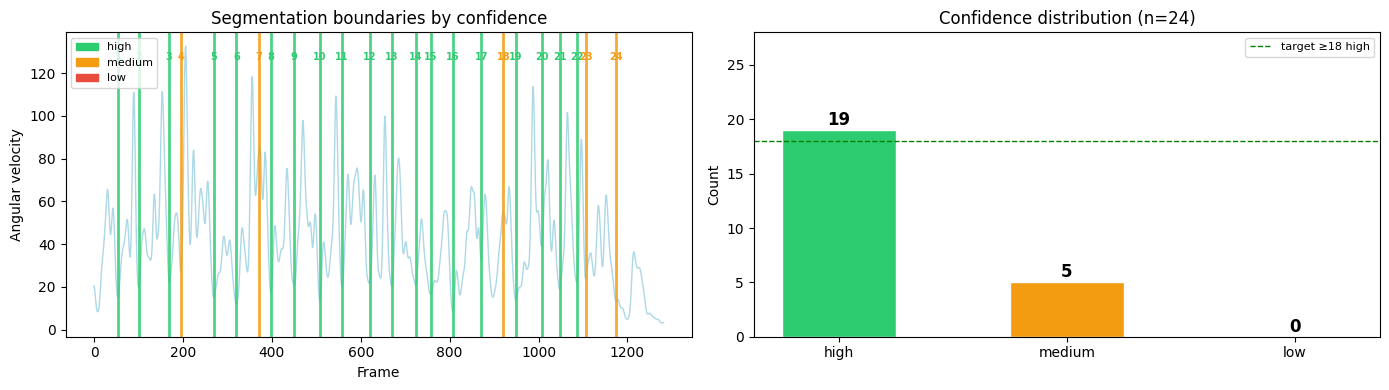


Master-on-master gate: PASS ✓  (19/24 high)


In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Left: velocity curve coloured by confidence ──────────────────────────────
ax = axes[0]
ax.plot(frame_indices[:-1], smoothed, color="lightblue", lw=1)

CONF_COLOR = {"high": "#2ecc71", "medium": "#f39c12", "low": "#e74c3c"}
for b in boundaries:
    c = CONF_COLOR[b.confidence]
    ax.axvline(b.frame, color=c, lw=2, alpha=0.85)
    ax.text(b.frame, smoothed.max() * 0.95, str(b.movement_number),
            ha="center", fontsize=7, color=c, fontweight="bold")

patches = [mpatches.Patch(color=v, label=k) for k, v in CONF_COLOR.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8)
ax.set_xlabel("Frame")
ax.set_ylabel("Angular velocity")
ax.set_title("Segmentation boundaries by confidence")

# ── Right: confidence bar chart ───────────────────────────────────────────────
ax2 = axes[1]
labels = ["high", "medium", "low"]
counts = [conf_count[l] for l in labels]
colors = [CONF_COLOR[l] for l in labels]
bars = ax2.bar(labels, counts, color=colors, edgecolor="white", width=0.5)
for bar, cnt in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             str(cnt), ha="center", va="bottom", fontsize=12, fontweight="bold")
ax2.set_ylim(0, NUM_MOVEMENTS + 4)
ax2.set_ylabel("Count")
ax2.set_title(f"Confidence distribution (n={NUM_MOVEMENTS})")
ax2.axhline(gate_target, color="green", lw=1, ls="--", label=f"target ≥{gate_target} high")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nMaster-on-master gate: {'PASS ✓' if gate else 'FAIL ✗'}  ({conf_count['high']}/{NUM_MOVEMENTS} high)")